# 🛒 Green Cart Ltd. — Q2 Sales & Customer Analysis
**Analyst Notebook | Data & Insights Team**

This notebook analyses sales, product, and customer data for Green Cart Ltd. to support the Q2 performance review. It covers data cleaning, feature engineering, summary tables, and visualisations.

---
## 📦 Step 1: Import Libraries and Load Data

We start by importing the libraries we need and loading all three datasets.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [ ]:
sales_df    = pd.read_csv('sales_data.csv')
product_df  = pd.read_csv('product_info.csv')
customer_df = pd.read_csv('customer_info.csv')

print('sales_df shape   :', sales_df.shape)
print('product_df shape :', product_df.shape)
print('customer_df shape:', customer_df.shape)

sales_df shape   : (3000, 10)
product_df shape : (30, 6)
customer_df shape: (500, 6)


In [ ]:
print('=== SALES DATA ===')
display(sales_df.head(3))

print('\n=== PRODUCT DATA ===')
display(product_df.head(3))

print('\n=== CUSTOMER DATA ===')
display(customer_df.head(3))

=== SALES DATA ===


,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
0,O966977,C00397,P0022,3,39.25,06-07-2025,Delivered,PayPal,Central,0.00
1,O696648,C00236,P0023,5,18.92,06-07-2025,DELAYED,credit card,North,0.00
2,O202644,C00492,P0011,1,29.68,07-07-2025,delivered,Bank Transfer,North,0.15



=== PRODUCT DATA ===


,product_id,product_name,category,launch_date,base_price,supplier_code
0,P0001,Storage Product 39,Storage,11-03-25,15.88,S339
1,P0002,Cleaning Product 82,Cleaning,18-08-24,34.23,S974
2,P0003,Cleaning Product 85,Cleaning,15-07-24,7.92,S745



=== CUSTOMER DATA ===


,customer_id,email,signup_date,gender,region,loyalty_tier
0,C00001,shaneramirez@gmail.com,26-04-25,Male,Central,Silver
1,C00002,jpeterson@bernard.com,11-08-24,Female,Central,gold
2,C00003,howardmaurice@yahoo.com,15-05-25,male,Central,gold


# ---- Fill missing discount_applied with 0 ----
# Assumption: if no discount is recorded, no discount was applied
sales_df["discount_applied"] = sales_df["discount_applied"].fillna(0.0)

# ---- Drop rows missing critical IDs or dates ----
# We cannot link orders without order_id, customer_id, or product_id
before = len(sales_df)
sales_df = sales_df.dropna(subset=["order_id", "customer_id", "product_id", "order_date"])
print(f"Rows dropped due to missing critical fields: {before - len(sales_df)}")

# ---- Remove duplicate orders ----
sales_df = sales_df.drop_duplicates(subset=["order_id"])
print(f"sales_df final shape: {sales_df.shape}")


### 2a — Check Missing Values

In [ ]:
print('Missing values in sales_df:')
print(sales_df.isnull().sum())

print('\nMissing values in product_df:')
print(product_df.isnull().sum())

print('\nMissing values in customer_df:')
print(customer_df.isnull().sum())

Missing values in sales_df:
order_id              1
customer_id           2
product_id            5
quantity              3
unit_price            1
order_date            2
delivery_status       3
payment_method        3
region                0
discount_applied    517
dtype: int64

Missing values in product_df:
product_id       0
product_name     0
category         0
launch_date      0
base_price       0
supplier_code    0
dtype: int64

Missing values in customer_df:
customer_id     3
email           6
signup_date     4
gender          4
region          3
loyalty_tier    2
dtype: int64


### 2b — Clean `sales_df`

In [ ]:
def clean_delivery(val):
    """Standardise delivery status to Delivered / Delayed / Cancelled"""
    if pd.isnull(val):
        return 'Unknown'
    v = str(val).strip().lower()
    if v in ['delivered', 'delrd']:
        return 'Delivered'
    elif v in ['delayed', 'delayed', 'delyd', ' delayed']:
        return 'Delayed'
    elif 'cancel' in v:
        return 'Cancelled'
    else:
        return 'Unknown'

sales_df['delivery_status'] = sales_df['delivery_status'].apply(clean_delivery)
print('Unique delivery_status values:', sales_df['delivery_status'].unique())

Unique delivery_status values: <StringArray>
['Delivered', 'Delayed', 'Cancelled', 'Unknown']
Length: 4, dtype: str


In [ ]:
def clean_payment(val):
    if pd.isnull(val):
        return 'Unknown'
    v = str(val).strip().lower()
    if 'bank' in v:
        return 'Bank Transfer'
    elif 'credit' in v:
        return 'Credit Card'
    elif 'paypal' in v:
        return 'PayPal'
    else:
        return v.title()

sales_df['payment_method'] = sales_df['payment_method'].apply(clean_payment)
print('Unique payment_method values:', sales_df['payment_method'].unique())

Unique payment_method values: <StringArray>
['PayPal', 'Credit Card', 'Bank Transfer', 'Unknown']
Length: 4, dtype: str


In [ ]:
sales_df['order_date'] = pd.to_datetime(sales_df['order_date'], errors='coerce')

sales_df['discount_applied'] = sales_df['discount_applied'].fillna(0.0)

before = len(sales_df)
sales_df = sales_df.dropna(subset=['order_id', 'customer_id', 'product_id', 'order_date'])
print(f'Rows dropped due to missing critical fields: {before - len(sales_df)}')

sales_df = sales_df.drop_duplicates(subset=['order_id'])
print(f'sales_df final shape: {sales_df.shape}')

Rows dropped due to missing critical fields: 1823
sales_df final shape: (1177, 10)


In [ ]:
sales_df["quantity"]         = pd.to_numeric(sales_df["quantity"], errors="coerce")
sales_df["unit_price"]       = pd.to_numeric(sales_df["unit_price"], errors="coerce")
sales_df["discount_applied"] = pd.to_numeric(sales_df["discount_applied"], errors="coerce").fillna(0.0)

sales_df = sales_df[
    (sales_df["quantity"] >= 0) &
    (sales_df["unit_price"] >= 0) &
    (sales_df["discount_applied"] >= 0)
]
print("Numeric columns validated. Final shape:", sales_df.shape)


Numeric columns validated. Final shape: (1173, 10)


### 2c — Clean `product_df`

In [ ]:
product_df['launch_date'] = pd.to_datetime(product_df['launch_date'], errors='coerce')

product_df['category']      = product_df['category'].str.strip().str.title()
product_df['product_name']  = product_df['product_name'].str.strip()

print('product_df cleaned. Shape:', product_df.shape)
display(product_df.head(3))

product_df cleaned. Shape: (30, 6)


,product_id,product_name,category,launch_date,base_price,supplier_code
0,P0001,Storage Product 39,Storage,2025-11-03,15.88,S339
1,P0002,Cleaning Product 82,Cleaning,2024-08-18,34.23,S974
2,P0003,Cleaning Product 85,Cleaning,2024-07-15,7.92,S745


### 2d — Clean `customer_df`

In [ ]:
def clean_loyalty(val):
    if pd.isnull(val):
        return 'Unknown'
    v = str(val).strip().lower()
    if v in ['gold', 'gld']:
        return 'Gold'
    elif v in ['silver', 'sllver']:
        return 'Silver'
    elif v in ['bronze', 'brnze']:
        return 'Bronze'
    else:
        return 'Unknown'

customer_df['loyalty_tier'] = customer_df['loyalty_tier'].apply(clean_loyalty)
print('Unique loyalty_tier values:', customer_df['loyalty_tier'].unique())

Unique loyalty_tier values: <StringArray>
['Silver', 'Gold', 'Bronze', 'Unknown']
Length: 4, dtype: str


In [ ]:
def clean_gender(val):
    if pd.isnull(val):
        return 'Unknown'
    v = str(val).strip().lower()
    if v in ['male', 'femle']:
        return 'Male' if v == 'male' else 'Female'
    elif v == 'female':
        return 'Female'
    elif v == 'other':
        return 'Other'
    else:
        return 'Unknown'

customer_df['gender'] = customer_df['gender'].apply(clean_gender)

customer_df['signup_date'] = pd.to_datetime(customer_df['signup_date'], errors='coerce')

customer_df['region']  = customer_df['region'].fillna('Unknown').str.strip()
customer_df['email']   = customer_df['email'].fillna('unknown@unknown.com')

customer_df = customer_df.dropna(subset=['customer_id'])
print('customer_df cleaned. Shape:', customer_df.shape)

customer_df cleaned. Shape: (497, 6)


---
## 🔗 Step 3: Merge the Data

We merge all three datasets into one combined DataFrame called `merged_df`.
- First: sales + products (on `product_id`)
- Then: result + customers (on `customer_id`)

We use `how='left'` to keep all sales records even if some product/customer info is missing.

In [ ]:
merged_df = pd.merge(sales_df, product_df, on='product_id', how='left')

merged_df = pd.merge(merged_df, customer_df, on='customer_id', how='left',
                     suffixes=('_sales', '_customer'))

print('Merged dataset shape:', merged_df.shape)
print('\nColumn names:')
print(merged_df.columns.tolist())

Merged dataset shape: (1173, 20)

Column names:
['order_id', 'customer_id', 'product_id', 'quantity', 'unit_price', 'order_date', 'delivery_status', 'payment_method', 'region_sales', 'discount_applied', 'product_name', 'category', 'launch_date', 'base_price', 'supplier_code', 'email', 'signup_date', 'gender', 'region_customer', 'loyalty_tier']


In [ ]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1173 entries, 0 to 1172
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          1173 non-null   str           
 1   customer_id       1173 non-null   str           
 2   product_id        1173 non-null   str           
 3   quantity          1173 non-null   float64       
 4   unit_price        1173 non-null   float64       
 5   order_date        1173 non-null   datetime64[us]
 6   delivery_status   1173 non-null   str           
 7   payment_method    1173 non-null   str           
 8   region_sales      1173 non-null   str           
 9   discount_applied  1173 non-null   float64       
 10  product_name      1173 non-null   str           
 11  category          1173 non-null   str           
 12  launch_date       1173 non-null   datetime64[us]
 13  base_price        1173 non-null   float64       
 14  supplier_code     1173 non-null   s

In [ ]:
display(merged_df.head())

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region_sales,discount_applied,product_name,category,launch_date,base_price,supplier_code,email,signup_date,gender,region_customer,loyalty_tier
0,O966977,C00397,P0022,3.00,39.25,2025-06-07,Delivered,PayPal,Central,0.00,Cleaning Product 86,Cleaning,2024-04-10,19.77,S924,jacquelinemartin@mills-logan.com,2024-08-09,Female,North,Silver
1,O696648,C00236,P0023,5.00,18.92,2025-06-07,Delayed,Credit Card,North,0.00,Outdoors Product 32,Outdoors,2025-01-18,36.04,S907,georgeweber@morgan.com,2024-06-08,Other,North,Gold
2,O202644,C00492,P0011,1.00,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,Kitchen Product 53,Kitchen,2025-03-25,11.08,S645,lcook@walters-smith.com,2024-09-25,Male,Central,Gold
3,O501803,C00031,P0003,1.00,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,Cleaning Product 85,Cleaning,2024-07-15,7.92,S745,smoore@gmail.com,2024-07-28,Female,Central,Gold
4,O322242,C00495,P0016,1.00,47.62,2025-08-07,Delayed,Credit Card,West,0.20,Cleaning Product 53,Cleaning,2025-02-20,26.71,S715,mcclainkatherine@hotmail.com,2024-09-18,Male,Central,Gold


---
## ⚙️ Step 4: Feature Engineering

We create new columns that will help us analyse the data more deeply.

In [ ]:
merged_df['revenue'] = (
    merged_df['quantity'] * merged_df['unit_price'] * (1 - merged_df['discount_applied'])
)

merged_df['order_week'] = merged_df['order_date'].dt.isocalendar().week.astype(int)

merged_df['price_band'] = pd.cut(
    merged_df['unit_price'],
    bins=[0, 15, 30, float('inf')],
    labels=['Low (<£15)', 'Medium (£15–30)', 'High (>£30)']
)

merged_df['days_to_order'] = (merged_df['order_date'] - merged_df['launch_date']).dt.days

merged_df['email_domain'] = merged_df['email'].str.split('@').str[-1]

merged_df['is_late'] = merged_df['delivery_status'] == 'Delayed'

merged_df['signup_month'] = merged_df['signup_date'].dt.month

print('New features created successfully!')
print(merged_df[['revenue', 'order_week', 'price_band', 'days_to_order', 'email_domain', 'is_late']].head())

New features created successfully!
   revenue  order_week       price_band  days_to_order       email_domain  \
0   117.75          23      High (>£30)            423    mills-logan.com   
1    94.60          23  Medium (£15–30)            140         morgan.com   
2    25.23          28  Medium (£15–30)            104  walters-smith.com   
3    26.21          32      High (>£30)            388          gmail.com   
4    38.10          32      High (>£30)            168        hotmail.com   

   is_late  
0    False  
1     True  
2    False  
3    False  
4     True  


---
## 📊 Step 5: Summary Tables

We use `groupby()` to summarise key patterns in the data.

### 5a — Weekly Revenue Trends by Region

In [ ]:
weekly_revenue = (
    merged_df.groupby(['order_week', 'region_sales'])['revenue']
    .sum()
    .reset_index()
    .rename(columns={'region_sales': 'region', 'revenue': 'total_revenue'})
)

weekly_revenue['total_revenue'] = weekly_revenue['total_revenue'].round(2)
display(weekly_revenue.head(10))

,order_week,region,total_revenue
0,1,East,173.83
1,1,North,20.78
2,1,South,55.88
3,1,West,325.32
4,2,Central,2223.81
5,2,East,838.75
6,2,North,1144.97
7,2,South,2233.79
8,2,West,1512.92
9,6,Central,1258.05


### 5b — Product Category Performance

In [ ]:
category_performance = (
    merged_df.groupby('category')
    .agg(
        total_revenue   = ('revenue', 'sum'),
        total_quantity  = ('quantity', 'sum'),
        avg_discount    = ('discount_applied', 'mean')
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

display(category_performance)

,category,total_revenue,total_quantity,avg_discount
0,Cleaning,37364.86,1406.00,0.08
1,Storage,17727.55,662.00,0.08
2,Outdoors,15266.47,593.00,0.08
3,Kitchen,12342.64,459.00,0.08
4,Personal Care,10626.64,385.00,0.09


### 5c — Customer Behaviour by Loyalty Tier and Signup Month

In [ ]:
customer_behaviour = (
    merged_df.groupby(['loyalty_tier', 'signup_month'])
    .agg(
        total_orders   = ('order_id', 'count'),
        total_revenue  = ('revenue', 'sum'),
        avg_order_val  = ('revenue', 'mean')
    )
    .round(2)
    .reset_index()
)

display(customer_behaviour.head(12))

,loyalty_tier,signup_month,total_orders,total_revenue,avg_order_val
0,Bronze,1.00,14,927.25,66.23
1,Bronze,2.00,29,2454.14,84.63
2,Bronze,3.00,23,1672.81,72.73
3,Bronze,4.00,13,1097.95,84.46
4,Bronze,5.00,15,882.40,58.83
5,Bronze,6.00,34,2519.05,74.09
6,Bronze,7.00,22,1684.39,76.56
7,Bronze,8.00,23,2125.32,92.41
8,Bronze,9.00,7,853.40,121.91
9,Bronze,10.00,28,2452.09,87.57


### 5d — Delivery Performance by Region and Price Band

In [ ]:
delivery_performance = (
    merged_df.groupby(['region_sales', 'price_band'])
    .agg(
        total_orders  = ('order_id', 'count'),
        late_orders   = ('is_late', 'sum'),
        late_rate_pct = ('is_late', 'mean')
    )
    .reset_index()
    .rename(columns={'region_sales': 'region'})
)

delivery_performance['late_rate_pct'] = (delivery_performance['late_rate_pct'] * 100).round(1)
display(delivery_performance)

,region,price_band,total_orders,late_orders,late_rate_pct
0,Central,Low (<£15),47,16,34.00
1,Central,Medium (£15–30),86,38,44.20
2,Central,High (>£30),115,47,40.90
3,East,Low (<£15),33,12,36.40
4,East,Medium (£15–30),101,49,48.50
5,East,High (>£30),103,42,40.80
6,North,Low (<£15),46,17,37.00
7,North,Medium (£15–30),75,36,48.00
8,North,High (>£30),111,37,33.30
9,South,Low (<£15),35,13,37.10


### 5e — Preferred Payment Methods by Loyalty Tier

In [ ]:
payment_by_tier = (
    merged_df.groupby(['loyalty_tier', 'payment_method'])
    .agg(order_count = ('order_id', 'count'))
    .reset_index()
    .sort_values(['loyalty_tier', 'order_count'], ascending=[True, False])
)

display(payment_by_tier)

,loyalty_tier,payment_method,order_count
1,Bronze,Credit Card,116
0,Bronze,Bank Transfer,70
2,Bronze,PayPal,62
4,Gold,Credit Card,315
5,Gold,PayPal,169
3,Gold,Bank Transfer,153
7,Silver,Credit Card,133
6,Silver,Bank Transfer,72
8,Silver,PayPal,71
9,Unknown,Credit Card,3


---
## 📈 Step 6: Visualisations

Six clearly labelled charts to communicate key findings.

### Chart 1 — Weekly Revenue Trends by Region (Line Plot)

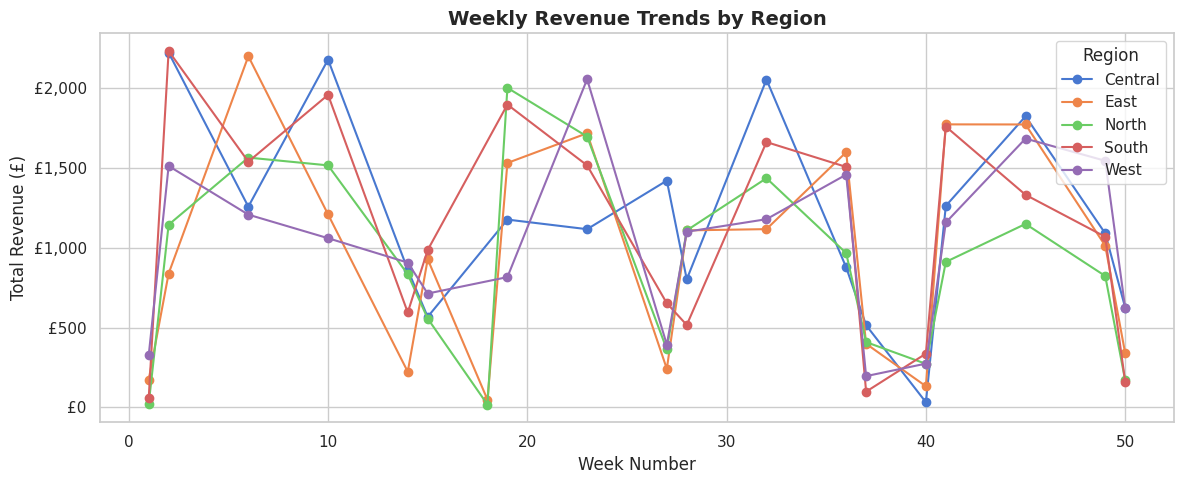

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for region, group in weekly_revenue.groupby('region'):
    ax.plot(group['order_week'], group['total_revenue'], marker='o', label=region)

ax.set_title('Weekly Revenue Trends by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Week Number')
ax.set_ylabel('Total Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(title='Region')
plt.tight_layout()
plt.savefig('chart1_weekly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2 — Top 5 Product Categories by Revenue (Bar Chart)

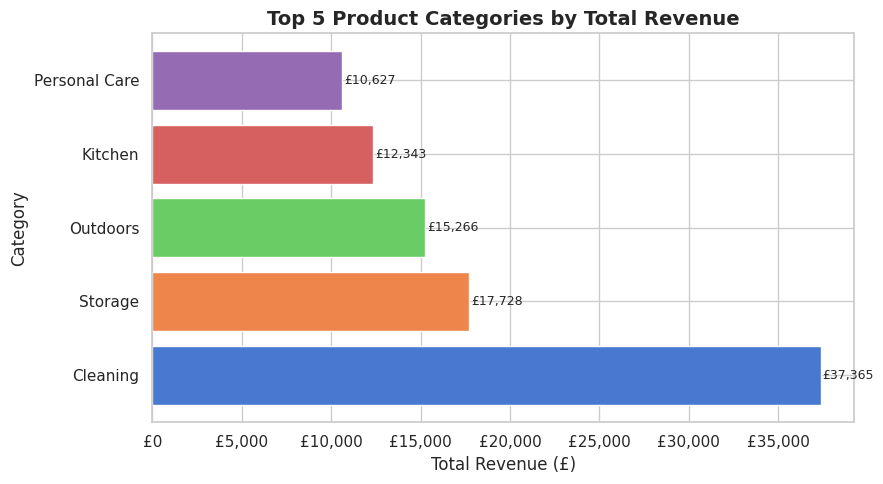

In [ ]:
top5 = category_performance.head(5)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top5['category'], top5['total_revenue'], color=sns.color_palette('muted', 5))

for bar in bars:
    width = bar.get_width()
    ax.text(width + 100, bar.get_y() + bar.get_height()/2,
            f'£{width:,.0f}', va='center', fontsize=9)

ax.set_title('Top 5 Product Categories by Total Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (£)')
ax.set_ylabel('Category')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('chart2_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3 — Quantity vs Discount Across Categories (Boxplot)

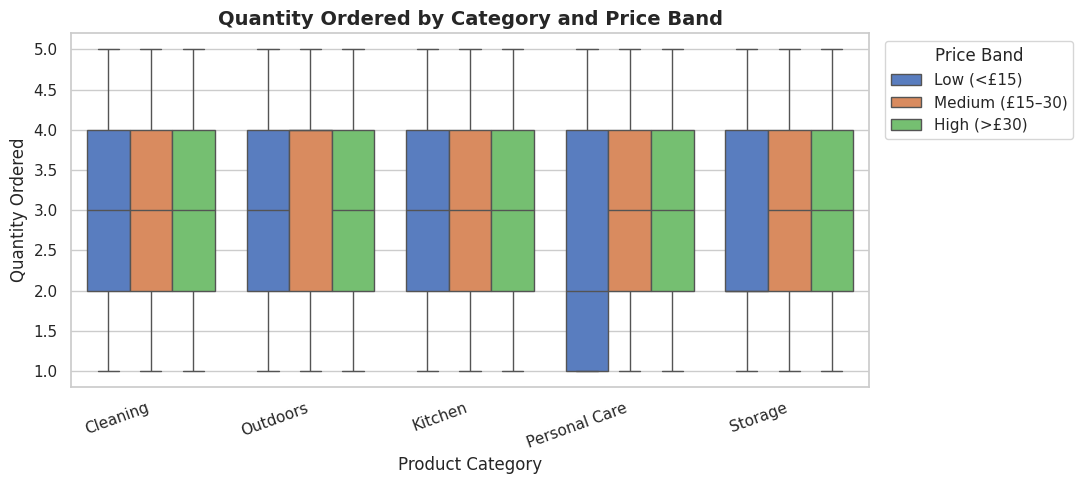

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
    data=merged_df,
    x='category',
    y='quantity',
    hue='price_band',
    ax=ax
)

ax.set_title('Quantity Ordered by Category and Price Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Product Category')
ax.set_ylabel('Quantity Ordered')
ax.legend(title='Price Band', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('chart3_quantity_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 4 — Correlation Heatmap (Revenue, Discount, Quantity)

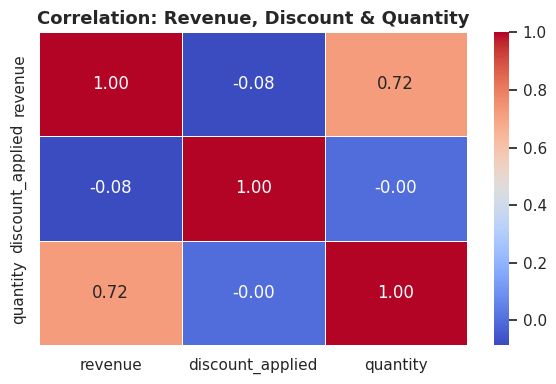

In [ ]:
corr_cols = merged_df[['revenue', 'discount_applied', 'quantity']].corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    corr_cols,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation: Revenue, Discount & Quantity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 5 — Orders by Loyalty Tier with Region (Countplot)

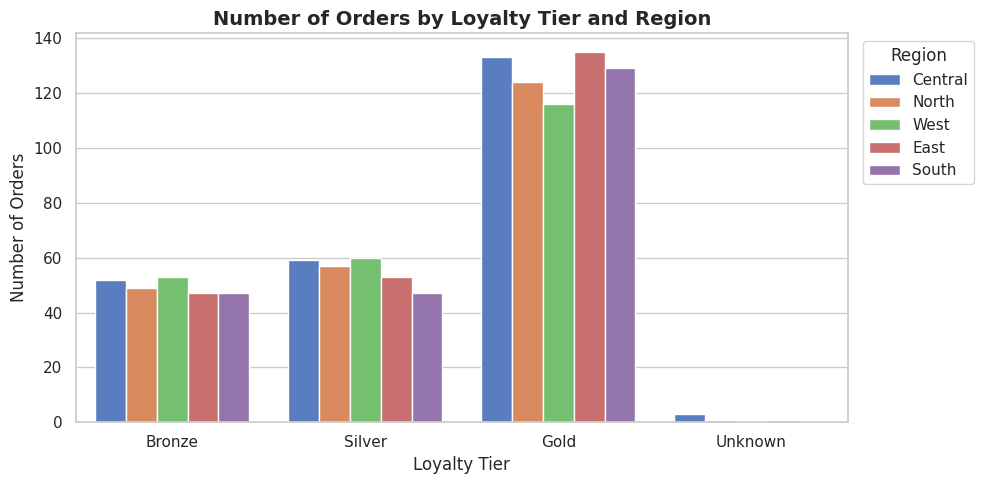

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

tier_order = ['Bronze', 'Silver', 'Gold', 'Unknown']

sns.countplot(
    data=merged_df,
    x='loyalty_tier',
    hue='region_sales',
    order=tier_order,
    ax=ax
)

ax.set_title('Number of Orders by Loyalty Tier and Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Loyalty Tier')
ax.set_ylabel('Number of Orders')
ax.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart5_loyalty_countplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 6 — Delivery Status by Price Band (Stacked Bar)

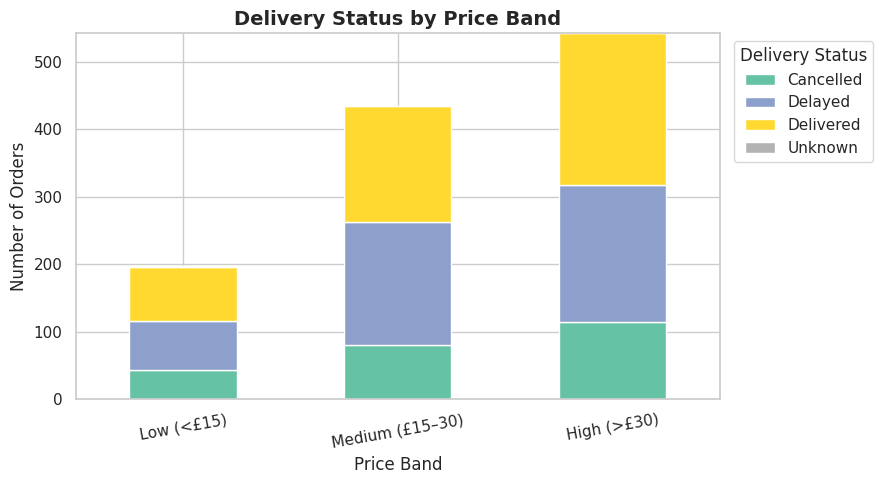

In [ ]:
delivery_pivot = (
    merged_df.groupby(['price_band', 'delivery_status'])['order_id']
    .count()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 5))
delivery_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')

ax.set_title('Delivery Status by Price Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Price Band')
ax.set_ylabel('Number of Orders')
ax.legend(title='Delivery Status', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('chart6_delivery_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ❓ Step 7: Business Questions Answered

### Q1 — Which product categories drive the most revenue, and in which regions?

In [ ]:
revenue_by_cat_region = (
    merged_df.groupby(['category', 'region_sales'])['revenue']
    .sum()
    .round(2)
    .reset_index()
    .rename(columns={'region_sales': 'region', 'revenue': 'total_revenue'})
    .sort_values('total_revenue', ascending=False)
)

display(revenue_by_cat_region.head(10))

,category,region,total_revenue
0,Cleaning,Central,7952.47
4,Cleaning,West,7627.07
3,Cleaning,South,7560.96
1,Cleaning,East,7502.75
2,Cleaning,North,6721.60
23,Storage,South,3909.96
20,Storage,Central,3676.00
10,Outdoors,Central,3424.64
21,Storage,East,3413.10
24,Storage,West,3383.54


### Q2 — Do discounts lead to more items sold?

In [ ]:
discounted     = merged_df[merged_df['discount_applied'] > 0]
not_discounted = merged_df[merged_df['discount_applied'] == 0]

print(f"Average quantity WITH discount:    {discounted['quantity'].mean():.2f}")
print(f"Average quantity WITHOUT discount: {not_discounted['quantity'].mean():.2f}")
print(f"\nCorrelation (discount vs quantity): {merged_df['discount_applied'].corr(merged_df['quantity']):.3f}")

Average quantity WITH discount:    3.01
Average quantity WITHOUT discount: 2.95

Correlation (discount vs quantity): -0.001


### Q3 — Which loyalty tier generates the most value?

In [ ]:
tier_value = (
    merged_df.groupby('loyalty_tier')
    .agg(
        total_revenue  = ('revenue', 'sum'),
        total_orders   = ('order_id', 'count'),
        avg_order_val  = ('revenue', 'mean')
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
)

display(tier_value)

,total_revenue,total_orders,avg_order_val
loyalty_tier,,,
Gold,51933.29,637,81.53
Silver,20724.01,276,75.09
Bronze,19922.13,248,80.33
Unknown,434.50,5,86.90


### Q4 — Are certain regions struggling with delivery delays?

In [ ]:
delay_by_region = (
    merged_df.groupby('region_sales')
    .agg(
        total_orders = ('order_id', 'count'),
        delayed      = ('is_late', 'sum'),
        delay_pct    = ('is_late', 'mean')
    )
    .reset_index()
    .rename(columns={'region_sales': 'region'})
)

delay_by_region['delay_pct'] = (delay_by_region['delay_pct'] * 100).round(1)
display(delay_by_region.sort_values('delay_pct', ascending=False))

,region,total_orders,delayed,delay_pct
1,East,237,103,43.50
0,Central,248,101,40.70
2,North,232,90,38.80
4,West,230,86,37.40
3,South,226,78,34.50


### Q5 — Do customer signup patterns influence purchasing activity?

In [ ]:
signup_activity = (
    merged_df.groupby('signup_month')
    .agg(
        total_orders  = ('order_id', 'count'),
        total_revenue = ('revenue', 'sum')
    )
    .round(2)
    .reset_index()
)

display(signup_activity)

,signup_month,total_orders,total_revenue
0,1.00,93,6990.06
1,2.00,93,7840.33
2,3.00,97,7744.69
3,4.00,110,9058.69
4,5.00,73,5878.23
5,6.00,102,7780.34
6,7.00,74,6038.20
7,8.00,100,8502.34
8,9.00,105,7896.79
9,10.00,118,9655.99


---
## 🌟 Step 8: Optional Stretch Tasks

### 8a — Query: Customers who signed up in Q2, ordered within 14 days, and got >20% discount

In [ ]:
stretch = merged_df[
    (merged_df["signup_month"] >= 4) &
    (merged_df["signup_month"] <= 6) &
    (merged_df["days_to_order"] <= 14) &
    (merged_df["discount_applied"] > 0.20)
]

print(f"Orders matching all three criteria: {len(stretch)}")
display(stretch[["order_id", "customer_id", "signup_month", "days_to_order", "discount_applied", "revenue"]].head(10))


Orders matching all three criteria: 0


,order_id,customer_id,signup_month,days_to_order,discount_applied,revenue


### 8b — Flag Underperforming Products

In [ ]:
product_flags = (
    merged_df.groupby('product_name')
    .agg(
        total_quantity = ('quantity', 'sum'),
        avg_discount   = ('discount_applied', 'mean'),
        delay_rate     = ('is_late', 'mean')
    )
    .round(3)
    .reset_index()
)


qty_threshold      = product_flags['total_quantity'].quantile(0.25)
discount_threshold = product_flags['avg_discount'].quantile(0.75)
delay_threshold    = product_flags['delay_rate'].quantile(0.75)

product_flags['underperforming'] = (
    (product_flags['total_quantity'] <= qty_threshold) &
    (product_flags['avg_discount']   >= discount_threshold) &
    (product_flags['delay_rate']     >= delay_threshold)
)

underperformers = product_flags[product_flags['underperforming']]
print(f'Underperforming products identified: {len(underperformers)}')
display(underperformers)

Underperforming products identified: 0


,product_name,total_quantity,avg_discount,delay_rate,underperforming


---
## ✅ Summary

This notebook has successfully:
1. **Loaded** all three datasets
2. **Cleaned** messy labels, missing values, and duplicates
3. **Merged** data into a single `merged_df`
4. **Engineered** six new features (revenue, order_week, price_band, days_to_order, email_domain, is_late)
5. **Summarised** patterns across regions, categories, loyalty tiers, and delivery performance
6. **Visualised** key findings with six clearly labelled charts
7. **Answered** all five business questions
8. **Completed** optional stretch tasks

Key findings and recommendations are covered in the accompanying PDF report.